# Age vs Spending Cluster Analysis

This project performs **customer segmentation** using the Mall Customer Dataset.  
The main topic is to group customers based on **Age** and **Spending Score** using **K-Means clustering**.

## 1. Import Libraries and Load Dataset

The required Python libraries are imported first. The dataset is loaded from a CSV file.

In [234]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

DATA_URL = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/refs/heads/master/Mall_Customers.csv"
df = pd.read_csv(DATA_URL)

## 2. Dataset Overview

The basic structure of the dataset is checked using `head()`, `info()`, and `describe()`.

In [235]:
print(df.head(3))
df.info()
df.describe()

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Missing Value Check

Missing values are checked before cleaning the dataset.

In [236]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 4. Data Cleaning

Rows with missing values and duplicate records are removed. In this dataset, the cleaning step confirms that the data is already clean.

In [237]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(200, 5)

## 5. Rename Columns

The long column names are renamed so that they are easier to use in code.

In [238]:
df = df.rename(
    columns={
        "Annual Income (k$)": "Annual_Income",
        "Spending Score (1-100)": "Spending_Score",
    }
)

## 6. Drop Unnecessary Column

`CustomerID` is only an identification number, so it is removed before analysis.

In [239]:
drop_cols = ["CustomerID"]
df = df.drop(columns=drop_cols)
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## 7. Categorical Column Check

The gender column is checked to understand the count of customers in each gender category.

In [240]:
print(df["Gender"].nunique())
df["Gender"].value_counts()

2


Gender
Female    112
Male       88
Name: count, dtype: int64

## 8. Numeric Feature Distribution

Histograms are used to check the distribution of `Age`, `Annual_Income`, and `Spending_Score`.

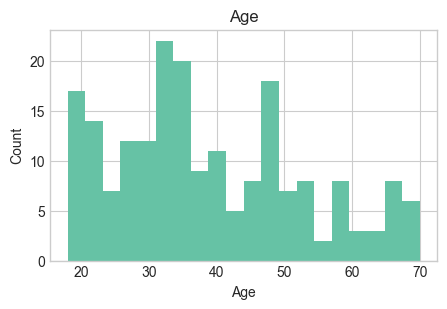

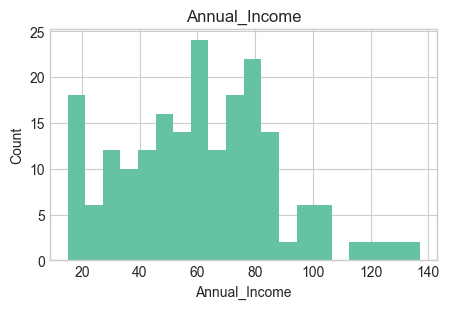

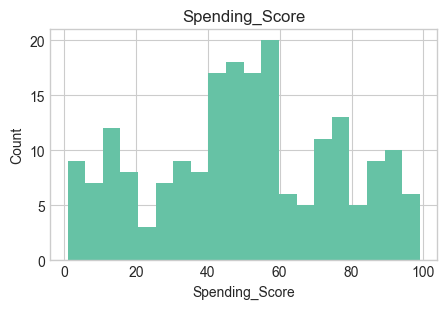

In [241]:
numeric_features = ["Age", "Annual_Income", "Spending_Score"]

for col in numeric_features:
    plt.figure(figsize=(5, 3))
    df[col].hist(bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 9. Correlation Heatmap

The heatmap shows the relationship between the numeric columns.

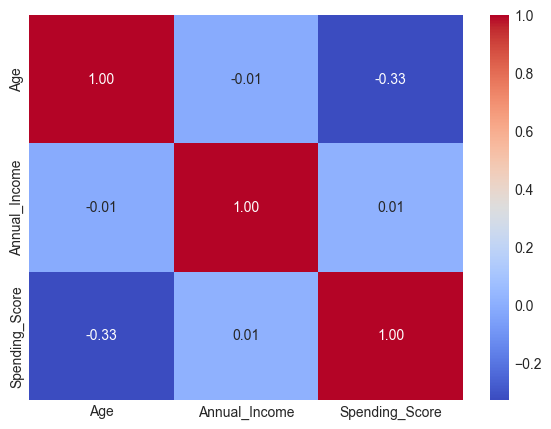

In [242]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.show()

## 10. Age vs Spending Score Visualization

This scatter plot shows how spending score changes with customer age.

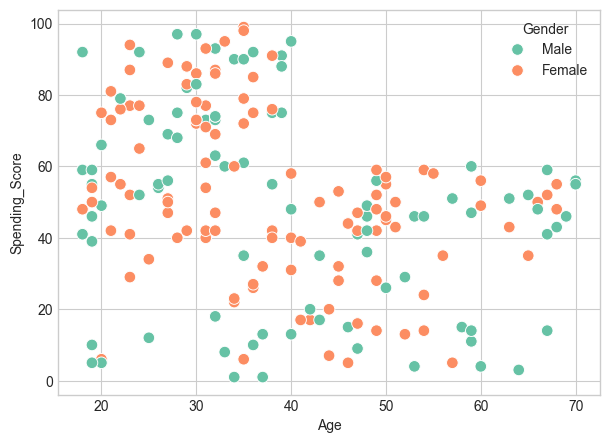

In [243]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending_Score",
    hue="Gender",
    s=70
)
plt.show()

## 11. Feature Selection and Scaling

Only `Age` and `Spending_Score` are selected for clustering because the project topic is Age vs Spending Cluster Analysis. Scaling is applied before K-Means because K-Means is distance-based.

In [244]:
features = ["Age", "Spending_Score"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 12. Elbow Method and Silhouette Score

Different values of K are tested from 2 to 10. Inertia is used for the elbow method and silhouette score is used to compare cluster separation.

In [245]:
metrics = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = km.fit_predict(X_scaled)
    metrics.append(
        {
            "K": k,
            "Inertia": km.inertia_,
            "Silhouette_Score": silhouette_score(X_scaled, labels)
        }
    )

metrics_df = pd.DataFrame(metrics)
metrics_df.round(4)

,K,Inertia,Silhouette_Score
0,2,189.3875,0.4721
1,3,124.3263,0.4395
2,4,89.7652,0.4384
3,5,71.2956,0.4475
4,6,53.1284,0.4566
5,7,45.9071,0.4115
6,8,39.1852,0.4048
7,9,34.1688,0.4086
8,10,28.8617,0.4381


## 13. Elbow Graph

The elbow graph helps decide a suitable number of clusters by checking the drop in inertia.

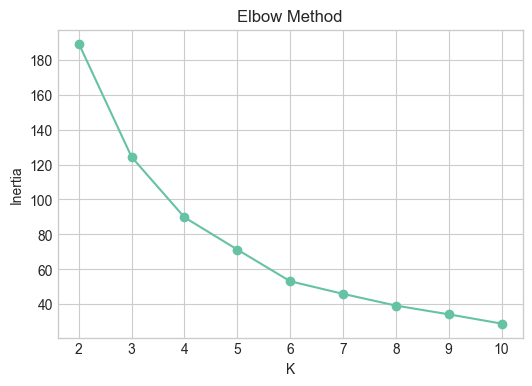

In [246]:
plt.figure(figsize=(6, 4))
plt.plot(
    metrics_df["K"],
    metrics_df["Inertia"],
    marker="o"
)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## 14. Silhouette Graph

The silhouette graph compares how well-separated the clusters are for each value of K.

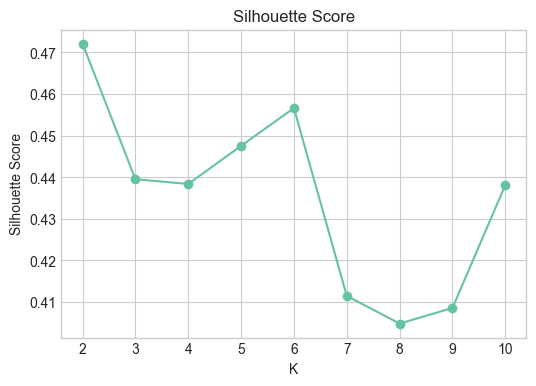

In [247]:
plt.figure(figsize=(6, 4))
plt.plot(
    metrics_df["K"],
    metrics_df["Silhouette_Score"],
    marker="o"
)
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

## 15. Apply Final K-Means Model

K = 4 is selected for the final model because it gives clear Age-Spending groups for this project.

In [248]:
selected_k = 4

kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = labels

## 16. Cluster Profile

The average age, income, and spending score of each cluster are calculated.

In [249]:
cluster_profile = (
    df.groupby("Cluster")[["Age", "Annual_Income", "Spending_Score"]]
      .mean()
      .round(2)
)

print(cluster_profile)

           Age  Annual_Income  Spending_Score
Cluster                                      
0        27.22          59.62           40.04
1        30.29          63.83           79.82
2        47.61          63.79           15.00
3        55.98          54.43           48.51


## 17. Final Cluster Visualization

The final scatter plot shows the customer clusters using Age and Spending Score.

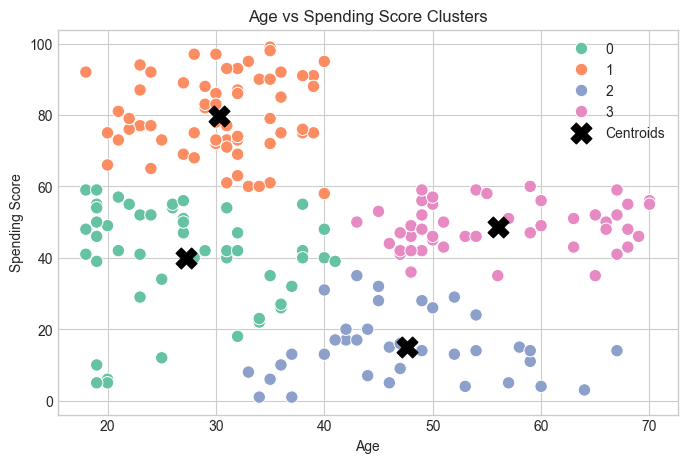

In [250]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending_Score",
    hue="Cluster",
    palette="Set2",
    s=80
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    marker="X",
    s=220,
    label="Centroids"
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score Clusters")
plt.legend()
plt.show()

## 18. Average Spending Score by Cluster

This bar graph compares the average spending score of each final cluster.

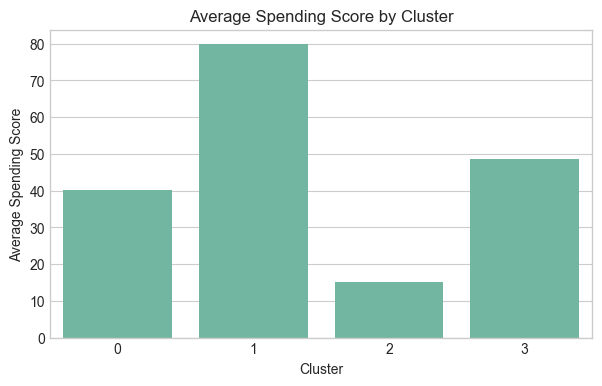

In [251]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=df,
    x="Cluster",
    y="Spending_Score",
    estimator=np.mean,
    errorbar=None
)
plt.xlabel("Cluster")
plt.ylabel("Average Spending Score")
plt.title("Average Spending Score by Cluster")
plt.show()